# Pareto Sampling Report

This notebook reads one or more `points.csv` files produced by `src/sample_exp.py`, builds Pareto fronts for every sampled run, and compares selected experiments.

Expected `points.csv` columns:

- `circuit`
- `run_id`
- `size`
- `depth`

Rows with missing `run_id` are treated as the original circuit point and are used for normalization.

In [1]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

## Inputs

Set `points_csv_paths` to the `points.csv` files you want to compare. By default, `run_name` is inferred from the parent experiment directory name.

In [6]:
# Fill this list with paths to points.csv files produced by src/sample_exp.py.
points_csv_paths = [
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv",
]

output_dir = Path('../outputs')
points_csv_paths = list(filter(lambda p: p.name == 'points.csv', output_dir.glob('**/*.csv')))
print(len(points_csv_paths))

# Optional friendly labels. If a path is missing here, its parent directory name is used.
run_name_overrides = {
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv": "gflownet_tb",
}
run_name_overrides = {str(p): '_'.join(p.parent.name.split('_')[1:-1]) for p in points_csv_paths}
print(run_name_overrides)

11
{'../outputs/2026-05-25/13:24_zhu2020_c6288_reproduce_78666/points.csv': 'zhu2020_c6288_reproduce', '../outputs/2026-05-25/12:02_zhu2020_bc0_reproduce_78666/points.csv': 'zhu2020_bc0_reproduce', '../outputs/2026-05-25/12:44_zhu2020_i10_reproduce_78668/points.csv': 'zhu2020_i10_reproduce', '../outputs/2026-05-25/11:26_zhu2020_apex1_reproduce_78666/points.csv': 'zhu2020_apex1_reproduce', '../outputs/2026-05-25/13:22_zhu2020_k2_reproduce_78668/points.csv': 'zhu2020_k2_reproduce', '../outputs/2026-05-25/12:50_zhu2020_c5315_reproduce_78666/points.csv': 'zhu2020_c5315_reproduce', '../outputs/2026-05-25/11:30_zhu2020_c7552_reproduce_78668/points.csv': 'zhu2020_c7552_reproduce', '../outputs/2026-05-25/12:13_zhu2020_dalu_reproduce_78668/points.csv': 'zhu2020_dalu_reproduce', '../outputs/2026-05-25/12:28_zhu2020_c1355_reproduce_78666/points.csv': 'zhu2020_c1355_reproduce', '../outputs/2026-05-25/13:53_zhu2020_mainpla_reproduce_78668/points.csv': 'zhu2020_mainpla_reproduce', '../outputs/2026-0

## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`. Hypervolume is the area dominated by the Pareto front and bounded by the original circuit reference point.

In [7]:
def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=(1.0, 1.0)):
    """2D minimization hypervolume relative to the original circuit point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }

## Load Points And Build Per-Run Metrics

`points_df` contains all normalized sampled points. `summary_df` is the requested dataframe with one row per `(run_name, run_id, circuit)`.

In [15]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    df["run_name"] = run_name or path.parent.name
    df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce").astype("Int64")
    df["size"] = pd.to_numeric(df["size"])
    df["depth"] = pd.to_numeric(df["depth"])
    return df


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

if not frames:
    raise ValueError("Fill points_csv_paths with at least one points.csv path, then rerun this cell.")

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
points_df = sample_df.merge(initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one")
if points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = points_df[points_df[["initial_size", "initial_depth"]].isna().any(axis=1)][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for:\n{missing}")

points_df["normalized_size"] = points_df["size"] / points_df["initial_size"]
points_df["normalized_depth"] = points_df["depth"] / points_df["initial_depth"]
points_df["size_reduction"] = 1.0 - points_df["normalized_size"]
points_df["depth_reduction"] = 1.0 - points_df["normalized_depth"]
points_df['circuit'] = points_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])

rows = []
fronts = {}
for (run_name, run_id, circuit), group in points_df.groupby(["run_name", "run_id", "circuit"], dropna=False):
    points = list(zip(group["normalized_size"], group["normalized_depth"]))
    front = pareto_front_min(points)
    fronts[(run_name, int(run_id), circuit)] = front
    rows.append(
        {
            "run_name": run_name,
            "run_id": int(run_id),
            "circuit": circuit,
            "hypervolume": hypervolume_min_2d(front),
            "number of nondominated points": len(front),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["circuit", "run_name", "run_id"]).reset_index(drop=True)
# summary_df['circuit'] = summary_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])
# print((summary_df.loc[0, 'circuit']))
summary_df

,run_name,run_id,circuit,hypervolume,number of nondominated points
0,zhu2020_c1355_reproduce,0,C1355,0.063034,1
1,zhu2020_c1355_reproduce,1,C1355,0.045024,1
2,zhu2020_c1355_reproduce,2,C1355,0.072039,1
3,zhu2020_c1355_reproduce,3,C1355,0.063034,1
4,zhu2020_c1355_reproduce,4,C1355,0.054029,1
5,zhu2020_c1355_reproduce,5,C1355,0.071963,2
6,zhu2020_c1355_reproduce,6,C1355,0.063034,1
7,zhu2020_c1355_reproduce,7,C1355,0.054029,1
8,zhu2020_c1355_reproduce,8,C1355,0.072039,1
9,zhu2020_c1355_reproduce,9,C1355,0.045024,1


## Average Metrics Across Runs

This aggregates the per-run dataframe by experiment and circuit, which is useful for RL/GFlowNet comparisons over multiple trained policies.

In [16]:
aggregate_summary_df = (
    summary_df.groupby(["run_name", "circuit"])
    .agg(
        n_runs=("run_id", "nunique"),
        hypervolume_mean=("hypervolume", "mean"),
        hypervolume_std=("hypervolume", "std"),
        hypervolume_min=("hypervolume", "min"),
        hypervolume_max=("hypervolume", "max"),
        nondominated_mean=("number of nondominated points", "mean"),
        nondominated_std=("number of nondominated points", "std"),
        nondominated_min=("number of nondominated points", "min"),
        nondominated_max=("number of nondominated points", "max"),
    )
    .reset_index()
)
aggregate_summary_df["hypervolume_stderr"] = aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df["nondominated_stderr"] = aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df

,run_name,circuit,n_runs,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,nondominated_stderr
0,tb_zhu_i10,i10,10,0.119150,0.005190,0.110796,0.127163,5.5,1.581139,3,8,0.001641,0.500000
1,zhu2020_apex1_reproduce,apex1,10,0.091901,0.008220,0.073739,0.102797,3.3,0.948683,2,5,0.002600,0.300000
2,zhu2020_bc0_reproduce,bc0,10,0.190126,0.013611,0.172962,0.217884,2.5,0.971825,1,4,0.004304,0.307318
3,zhu2020_c1355_reproduce,C1355,10,0.060325,0.010432,0.045024,0.072039,1.1,0.316228,1,2,0.003299,0.100000
4,zhu2020_c5315_reproduce,C5315,10,0.081208,0.007376,0.063838,0.087408,2.2,1.229273,1,4,0.002332,0.388730
5,zhu2020_c6288_reproduce,C6288,10,0.051622,0.000000,0.051622,0.051622,1.0,0.000000,1,1,0.000000,0.000000
6,zhu2020_c7552_reproduce,C7552,10,0.000000,0.000000,0.000000,0.000000,6.4,1.837873,4,10,0.000000,0.581187
7,zhu2020_dalu_reproduce,dalu,10,0.000000,0.000000,0.000000,0.000000,2.2,0.421637,2,3,0.000000,0.133333
8,zhu2020_i10_reproduce,i10,10,0.029500,0.028643,0.000000,0.099335,3.1,1.595131,1,6,0.009058,0.504425
9,zhu2020_k2_reproduce,k2,10,0.181279,0.037237,0.079514,0.206489,2.4,1.264911,1,5,0.011775,0.400000


## Pairwise Experiment Comparison

Choose a circuit and a set of experiments. Pairwise values are computed over all run pairs between two experiments and then summarized.

In [23]:
# Choose the comparison target.
# selected_circuit = points_df["circuit"].iloc[0]
selected_circuit = 'i10'
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())


print("Selected circuit:", selected_circuit)
print("Selected experiments:", selected_experiments)

Selected circuit: i10
Selected experiments: ['tb_zhu_i10', 'zhu2020_i10_reproduce']


In [24]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)

    eps_values = []
    dominance_values = []
    for source_run_id, source_front in source_fronts.items():
        for target_run_id, target_front in target_fronts.items():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "n_run_pairs": eps_summary["n"],
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,source_run_name,target_run_name,circuit,n_run_pairs,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,tb_zhu_i10,zhu2020_i10_reproduce,i10,100,-0.001293,0.011130,0.001113,-0.030654,0.01757,0.628500,0.411308,0.041131,0.0,1.0
1,zhu2020_i10_reproduce,tb_zhu_i10,i10,100,0.272000,0.099277,0.009928,0.040000,0.44000,0.065893,0.158045,0.015805,0.0,0.8


## Print Selected Pareto Fronts

This prints a Pareto front for each selected experiment on the chosen circuit. The front is pooled across selected runs for that experiment, then filtered again for nondominated normalized `(size, depth)` points.

In [26]:
# Choose which runs to include in the printed front. None means all runs for each experiment.
selected_run_ids = None  # example: [0, 1, 2]

front_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}")
print(f"Experiments: {selected_experiments}")
print(selected_front_df.to_string(index=False))
selected_front_df

Pareto fronts for circuit: i10
Experiments: ['tb_zhu_i10', 'zhu2020_i10_reproduce']
             run_name circuit  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
           tb_zhu_i10     i10         0.632523              0.88        0.367477             0.12  1692     44
           tb_zhu_i10     i10         0.640748              0.82        0.359252             0.18  1714     41
           tb_zhu_i10     i10         0.642243              0.74        0.357757             0.26  1718     37
           tb_zhu_i10     i10         0.642617              0.72        0.357383             0.28  1719     36
           tb_zhu_i10     i10         0.656449              0.66        0.343551             0.34  1756     33
           tb_zhu_i10     i10         0.663551              0.64        0.336449             0.36  1775     32
zhu2020_i10_reproduce     i10         0.634393              1.06        0.365607            -0.06  1697     53
zhu2020_i10_reproduce     i1

,run_name,circuit,normalized_size,normalized_depth,size_reduction,depth_reduction,size,depth
0,tb_zhu_i10,i10,0.632523,0.88,0.367477,0.12,1692,44
1,tb_zhu_i10,i10,0.640748,0.82,0.359252,0.18,1714,41
2,tb_zhu_i10,i10,0.642243,0.74,0.357757,0.26,1718,37
3,tb_zhu_i10,i10,0.642617,0.72,0.357383,0.28,1719,36
4,tb_zhu_i10,i10,0.656449,0.66,0.343551,0.34,1756,33
5,tb_zhu_i10,i10,0.663551,0.64,0.336449,0.36,1775,32
6,zhu2020_i10_reproduce,i10,0.634393,1.06,0.365607,-0.06,1697,53
7,zhu2020_i10_reproduce,i10,0.634766,1.02,0.365234,-0.02,1698,51
8,zhu2020_i10_reproduce,i10,0.637009,0.98,0.362991,0.02,1704,49
9,zhu2020_i10_reproduce,i10,0.638131,0.96,0.361869,0.04,1707,48


## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected experiment on the selected circuit in normalized minimization space. Lower-left is better.

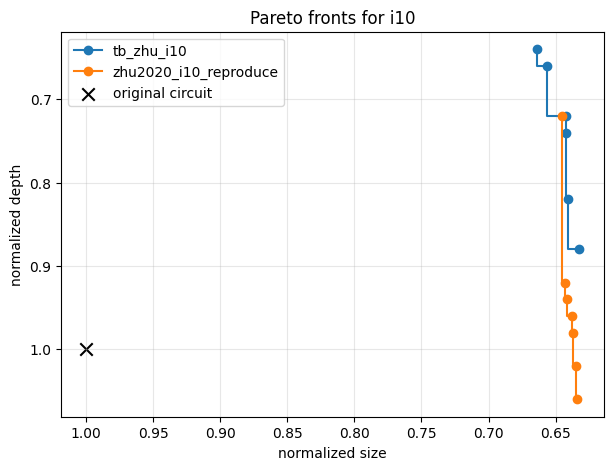

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pareto fronts for {Path(selected_circuit).name}")
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()